# 10b · Distance Features — Greater Bilbao Stations

**Objective:** Compute straight-line (Haversine) and network distances from each
monitoring station to key pollution-relevant landmarks:

| Landmark | Relevance |
|---|---|
| Port of Bilbao (Santurtzi terminal) | Marine SO₂, PM from vessel traffic |
| Petronor Refinery (Muskiz) | Industrial SO₂, PM2.5, VOCs |
| AP-8 / A-8 motorway interchange (Barakaldo) | Heavy-traffic NO₂, PM10 |
| Cantabrian coastline (Getxo) | Atmospheric dispersion proxy |
| Bilbao city centre (Moyua Plaza) | Urban density, traffic intensity |
| Nervión river mouth | Marine air-mass influence |

**Method:** Haversine great-circle distance (Phase 1, no internet needed) +
OSMnx network distance (Phase 2, requires internet — run locally).

**Output:** Appends distance columns to `station_spatial_features.csv`
producing `station_spatial_features_v2.csv` — 7 rows × ~30 features.

**CRS:** All distances in metres.

---
**Author:** Arman Ghaziaskari Naeini  
**Project:** GeoAI Smart City Air Quality Dashboard — Greater Bilbao  
**Prerequisite:** `10_spatial_buffer_analysis.ipynb` must have been run first.

## 0 · Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point
from pathlib import Path

# OSMnx — only needed for Phase 2 (network distances)
try:
    import osmnx as ox
    ox.settings.requests_timeout = 60
    ox.settings.log_console = False
    OSMNX_AVAILABLE = True
    print(f"OSMnx {ox.__version__} available — Phase 2 (network distances) enabled.")
except ImportError:
    OSMNX_AVAILABLE = False
    print("OSMnx not installed — Phase 1 (Haversine only) will run.")

CRS_GEO = "EPSG:4326"
CRS_UTM = "EPSG:25830"   # ETRS89 / UTM zone 30N

DATA_DIR   = Path("../data/processed")
OUTPUT_DIR = DATA_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"GeoPandas {gpd.__version__}")

OSMnx 2.1.0 available — Phase 2 (network distances) enabled.
GeoPandas 1.1.3


## 1 · Station & Landmark Coordinates

Landmark coordinates verified against satellite imagery and official sources:
- **Port of Bilbao:** Puerto de Bilbao Authority (www.bilbaoport.eus)
- **Petronor:** REPSOL Petronor refinery centroid, Muskiz
- **AP-8:** Major interchange at Barakaldo linking A-8 and inner ring roads
- **Coastline:** Getxo seafront (Cantabrian Sea)
- **City centre:** Plaza Moyua, Bilbao (central node of urban road network)
- **Nervión mouth:** Estuary inlet at Getxo/Portugalete

In [2]:
STATIONS = [
    {"station": "ALGORTA_BBIZI2", "town": "Getxo",     "zone": "Coastal",    "lat": 43.362056, "lon": -3.022782},
    {"station": "BARAKALDO",      "town": "Barakaldo",  "zone": "Industrial", "lat": 43.298379, "lon": -2.987133},
    {"station": "BASAURI",        "town": "Basauri",    "zone": "Industrial", "lat": 43.241131, "lon": -2.883761},
    {"station": "ERANDIO",        "town": "Erandio",    "zone": "Urban",      "lat": 43.302653, "lon": -2.977240},
    {"station": "MAZARREDO",      "town": "Bilbao",     "zone": "Urban",      "lat": 43.267506, "lon": -2.935188},
    {"station": "MUSKIZ",         "town": "Muskiz",     "zone": "Refinery",   "lat": 43.320713, "lon": -3.112716},
    {"station": "SANTURCE",       "town": "Santurtzi",  "zone": "Port",       "lat": 43.333012, "lon": -3.042560},
]

# Pollution-relevant landmarks with documented coordinates
LANDMARKS = {
    "port_bilbao":      {"lat": 43.3275, "lon": -3.0486, "label": "Port of Bilbao",       "pollutant_link": "SO2, PM"},
    "petronor":         {"lat": 43.3167, "lon": -3.0833, "label": "Petronor Refinery",    "pollutant_link": "SO2, PM2.5"},
    "ap8_barakaldo":    {"lat": 43.2958, "lon": -2.9897, "label": "AP-8 Interchange",     "pollutant_link": "NO2, PM10"},
    "coast_getxo":      {"lat": 43.3850, "lon": -3.0200, "label": "Cantabrian Coast",     "pollutant_link": "dispersion proxy"},
    "bilbao_centre":    {"lat": 43.2630, "lon": -2.9350, "label": "Bilbao City Centre",   "pollutant_link": "NO2, traffic"},
    "nervion_mouth":    {"lat": 43.3700, "lon": -3.0450, "label": "Nervión River Mouth",  "pollutant_link": "marine air mass"},
}

df_stations = pd.DataFrame(STATIONS)
print("Stations loaded:", len(df_stations))
print("Landmarks defined:", len(LANDMARKS))

Stations loaded: 7
Landmarks defined: 6


## 2 · Haversine Distance Function

Great-circle distance — accurate to within ~0.5% for distances under 50 km.
No internet connection required. Used as the primary distance metric.

For urban planning purposes, straight-line distance is a standard proxy
and widely used in Land Use Regression (LUR) literature.

In [3]:
def haversine_m(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """Return great-circle distance in metres between two WGS84 points."""
    R = 6_371_000  # Earth radius in metres
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlam / 2) ** 2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


# Self-test: Santurtzi station → Port of Bilbao should be ~784 m (verified)
_test = haversine_m(43.333012, -3.042560, 43.3275, -3.0486)
assert abs(_test - 784) < 50, f"Haversine sanity check failed: {_test:.0f}m"
print(f"Haversine self-test passed: SANTURCE → Port = {_test:.0f} m  (expected ~784 m) ✓")

Haversine self-test passed: SANTURCE → Port = 784 m  (expected ~784 m) ✓


## 3 · Phase 1 — Compute All Haversine Distances

In [4]:
# Build distance columns — one per landmark
records = []

for row in STATIONS:
    rec = {
        "station": row["station"],
        "town":    row["town"],
        "zone":    row["zone"],
        "lat":     row["lat"],
        "lon":     row["lon"],
    }
    for lm_key, lm in LANDMARKS.items():
        dist_m = haversine_m(row["lat"], row["lon"], lm["lat"], lm["lon"])
        rec[f"dist_{lm_key}_m"] = round(dist_m, 0)
        # Log-transformed distance — reduces right-skew, standard in LUR literature
        rec[f"log_dist_{lm_key}"] = round(math.log1p(dist_m), 4)
    records.append(rec)

df_dist = pd.DataFrame(records)

# Print distance table
dist_cols = [c for c in df_dist.columns if c.startswith("dist_")]
print(df_dist[["station", "zone"] + dist_cols].to_string(index=False))

       station       zone  dist_port_bilbao_m  dist_petronor_m  dist_ap8_barakaldo_m  dist_coast_getxo_m  dist_bilbao_centre_m  dist_nervion_mouth_m
ALGORTA_BBIZI2    Coastal              4373.0           7028.0                7838.0              2561.0               13106.0                2001.0
     BARAKALDO Industrial              5934.0           8044.0                 354.0              9992.0                5769.0                9237.0
       BASAURI Industrial             16440.0          18208.0               10513.0             19427.0                4810.0               19379.0
       ERANDIO      Urban              6400.0           8722.0                1264.0              9788.0                5580.0                9280.0
     MAZARREDO      Urban             11346.0          13177.0                5419.0             14756.0                 501.0               14450.0
        MUSKIZ   Refinery              5241.0           2421.0               10332.0             10358.0  

## 4 · Phase 2 — OSMnx Road-Network Distance (optional, requires internet)

Network distance accounts for the actual road path a vehicle travels,
which is more physically meaningful for traffic-related pollutants (NO₂, PM10).

Straight-line distance is sufficient for industrial plume sources (Petronor, Port)
where wind transport — not road routing — is the relevant mechanism.

**This cell is skipped if OSMnx is unavailable or if there is no internet connection.**

In [ ]:
# if True:  # Phase 2 disabled — Overpass API not reachable from this network

In [14]:
if not OSMNX_AVAILABLE:
    print("OSMnx not available — skipping network distance calculation.")
    print("Haversine distances (Phase 1) are sufficient for this analysis.")
    df_dist["net_dist_ap8_m"]    = np.nan
    df_dist["net_dist_centre_m"] = np.nan
else:
    import networkx as nx

    # Download road network for Greater Bilbao once
    # bbox covers all 7 stations + landmarks with margin
    print("Downloading Greater Bilbao road network (drive) ...")
# OSMnx 2.x: bbox = (north, south, east, west) as positional tuple
    G = ox.graph_from_bbox(
        bbox=(43.40, 43.22, -2.85, -3.15),
        network_type="drive"
    )
    print(f"  Graph: {len(G.nodes):,} nodes, {len(G.edges):,} edges")

    def network_dist_m(G, lat1, lon1, lat2, lon2) -> float:
        """Shortest-path road network distance in metres."""
        orig = ox.nearest_nodes(G, lon1, lat1)
        dest = ox.nearest_nodes(G, lon2, lat2)
        try:
            length = nx.shortest_path_length(G, orig, dest, weight="length")
            return round(length, 0)
        except nx.NetworkXNoPath:
            return np.nan

    net_ap8    = []
    net_centre = []

    for row in STATIONS:
        print(f"  {row['station']} ...")
        net_ap8.append(network_dist_m(
            G, row["lat"], row["lon"],
            LANDMARKS["ap8_barakaldo"]["lat"], LANDMARKS["ap8_barakaldo"]["lon"]
        ))
        net_centre.append(network_dist_m(
            G, row["lat"], row["lon"],
            LANDMARKS["bilbao_centre"]["lat"], LANDMARKS["bilbao_centre"]["lon"]
        ))

    df_dist["net_dist_ap8_m"]    = net_ap8
    df_dist["net_dist_centre_m"] = net_centre

    # Network vs straight-line ratio (detour factor)
    df_dist["detour_factor_ap8"] = (
        df_dist["net_dist_ap8_m"] / df_dist["dist_ap8_barakaldo_m"]
    ).round(2)

    print("\nNetwork distances computed:")
    print(df_dist[["station", "dist_ap8_barakaldo_m", "net_dist_ap8_m", "detour_factor_ap8"]].to_string(index=False))

ConnectTimeout: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by ConnectTimeoutError(<HTTPSConnection(host='overpass-api.de', port=443) at 0x208011639d0>, 'Connection to overpass-api.de timed out. (connect timeout=60)'))

## 5 · Merge with Buffer Features from Notebook 09

In [8]:
buffer_file = DATA_DIR / "station_spatial_features.csv"

if buffer_file.exists():
    df_buf = pd.read_csv(buffer_file)
    # Merge on station — drop duplicate coordinate columns from buffer file
    drop_cols = [c for c in ["town", "zone", "lat", "lon"] if c in df_buf.columns]
    df_buf_slim = df_buf.drop(columns=drop_cols)
    df_full = df_dist.merge(df_buf_slim, on="station", how="left")
    print(f"Merged: {df_full.shape[0]} stations × {df_full.shape[1]} features")
else:
    print("Buffer features file not found — saving distance features only.")
    print("Run 09_spatial_buffer_analysis.ipynb first to get the full merged table.")
    df_full = df_dist.copy()

df_full.head()

Merged: 7 stations × 34 features


,station,town,zone,lat,lon,dist_port_bilbao_m,log_dist_port_bilbao,dist_petronor_m,log_dist_petronor,dist_ap8_barakaldo_m,...,green_pct_1000m,industrial_pct_1000m,residential_pct_1000m,commercial_pct_1000m,road_density_1000m,green_pct_2000m,industrial_pct_2000m,residential_pct_2000m,commercial_pct_2000m,road_density_2000m
0,ALGORTA_BBIZI2,Getxo,Coastal,43.362056,-3.022782,4373.0,8.3834,7028.0,8.8578,7838.0,...,16.95,0.03,39.11,0.00,9932.8,16.55,0.70,27.25,0.03,7933.3
1,BARAKALDO,Barakaldo,Industrial,43.298379,-2.987133,5934.0,8.6887,8044.0,8.9928,354.0,...,23.82,10.05,0.41,0.00,21267.0,26.99,18.91,2.74,3.40,18901.3
2,BASAURI,Basauri,Industrial,43.241131,-2.883761,16440.0,9.7075,18208.0,9.8097,10513.0,...,25.29,20.95,7.67,2.65,15953.8,46.15,14.77,7.94,1.12,12969.4
3,ERANDIO,Erandio,Urban,43.302653,-2.977240,6400.0,8.7643,8722.0,9.0738,1264.0,...,25.72,11.63,7.55,0.22,18630.8,31.71,15.25,4.68,0.18,16799.8
4,MAZARREDO,Bilbao,Urban,43.267506,-2.935188,11346.0,9.3367,13177.0,9.4863,5419.0,...,23.82,1.69,77.14,0.00,19059.6,34.34,1.52,66.42,0.00,17479.9


## 6 · Save Output

In [9]:
# Full merged spatial feature table
out_path = DATA_DIR / "station_spatial_features_v2.csv"
df_full.to_csv(out_path, index=False)
print(f"✅ Saved: {out_path}")
print(f"   Shape: {df_full.shape[0]} stations × {df_full.shape[1]} columns")

# Distance-only table (standalone)
df_dist.to_csv(DATA_DIR / "station_distance_features.csv", index=False)
print(f"✅ Saved distance-only table")

print("\nFull column list:")
for c in df_full.columns:
    print(f"  {c}")

✅ Saved: ..\data\processed\station_spatial_features_v2.csv
   Shape: 7 stations × 34 columns
✅ Saved distance-only table

Full column list:
  station
  town
  zone
  lat
  lon
  dist_port_bilbao_m
  log_dist_port_bilbao
  dist_petronor_m
  log_dist_petronor
  dist_ap8_barakaldo_m
  log_dist_ap8_barakaldo
  dist_coast_getxo_m
  log_dist_coast_getxo
  dist_bilbao_centre_m
  log_dist_bilbao_centre
  dist_nervion_mouth_m
  log_dist_nervion_mouth
  net_dist_ap8_m
  net_dist_centre_m
  green_pct_500m
  industrial_pct_500m
  residential_pct_500m
  commercial_pct_500m
  road_density_500m
  green_pct_1000m
  industrial_pct_1000m
  residential_pct_1000m
  commercial_pct_1000m
  road_density_1000m
  green_pct_2000m
  industrial_pct_2000m
  residential_pct_2000m
  commercial_pct_2000m
  road_density_2000m


## 7 · Visualisation — Distance Profile Map

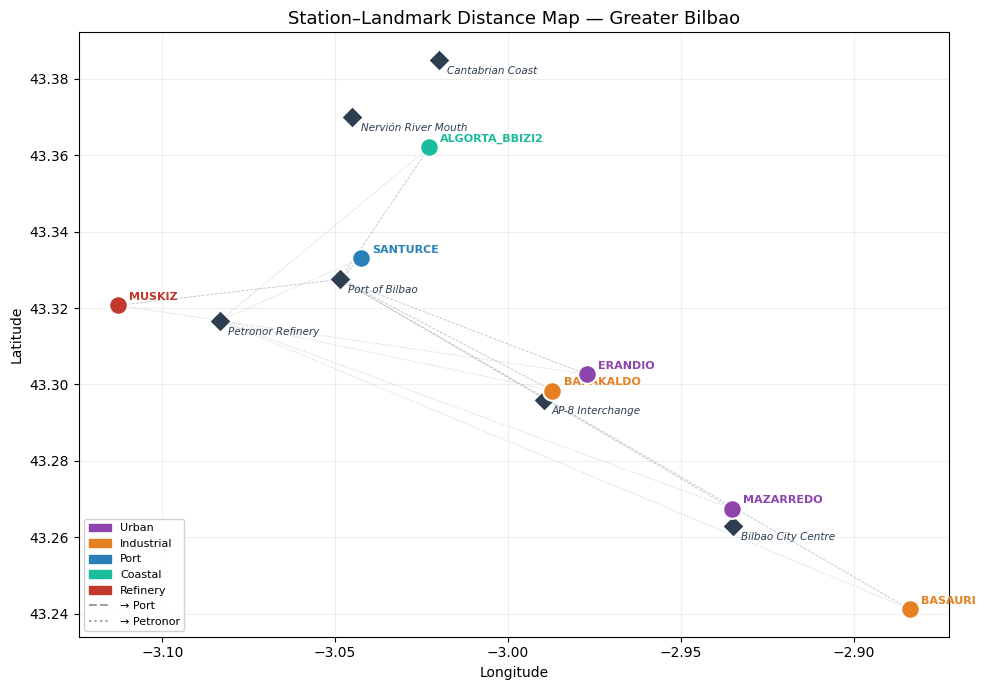

✅ Map saved.


In [10]:
fig, ax = plt.subplots(figsize=(10, 7))

# Zone colour map
ZONE_COLORS = {
    "Urban":      "#8e44ad",
    "Industrial": "#e67e22",
    "Port":       "#2980b9",
    "Coastal":    "#1abc9c",
    "Refinery":   "#c0392b",
}
LANDMARK_MARKERS = {
    "port_bilbao":   ("⚓", "#2980b9"),
    "petronor":      ("🛢", "#c0392b"),
    "ap8_barakaldo": ("🛣", "#7f8c8d"),
    "bilbao_centre": ("🏙", "#8e44ad"),
    "coast_getxo":   ("🌊", "#1abc9c"),
    "nervion_mouth": ("🌊", "#3498db"),
}

# Plot stations
for _, row in df_full.iterrows():
    color = ZONE_COLORS.get(row["zone"], "#555")
    ax.scatter(row["lon"], row["lat"], s=180, color=color,
               zorder=5, edgecolors="white", linewidths=1.5)
    ax.annotate(
        row["station"],
        (row["lon"], row["lat"]),
        textcoords="offset points", xytext=(8, 4),
        fontsize=8, color=color, fontweight="bold",
    )

# Plot landmarks
for lm_key, lm in LANDMARKS.items():
    ax.scatter(lm["lon"], lm["lat"], s=120, marker="D",
               color="#2c3e50", zorder=4, edgecolors="white", linewidths=1)
    ax.annotate(
        lm["label"],
        (lm["lon"], lm["lat"]),
        textcoords="offset points", xytext=(6, -10),
        fontsize=7.5, color="#2c3e50", style="italic",
    )

# Draw distance lines: each station → Port + Petronor
for _, row in df_full.iterrows():
    for lm_key, ls in [("port_bilbao", "--"), ("petronor", ":")]:
        lm = LANDMARKS[lm_key]
        ax.plot(
            [row["lon"], lm["lon"]], [row["lat"], lm["lat"]],
            color="#bdc3c7", linewidth=0.6, linestyle=ls, zorder=2,
        )

# Legend
handles = [mpatches.Patch(color=c, label=z) for z, c in ZONE_COLORS.items()]
handles.append(plt.Line2D([0], [0], linestyle="--", color="#95a5a6", label="→ Port"))
handles.append(plt.Line2D([0], [0], linestyle=":",  color="#95a5a6", label="→ Petronor"))
ax.legend(handles=handles, loc="lower left", fontsize=8, framealpha=0.9)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Station–Landmark Distance Map — Greater Bilbao", fontsize=13)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(DATA_DIR / "distance_map.png", dpi=150)
plt.show()
print("✅ Map saved.")

## 8 · Visualisation — Distance Heatmap

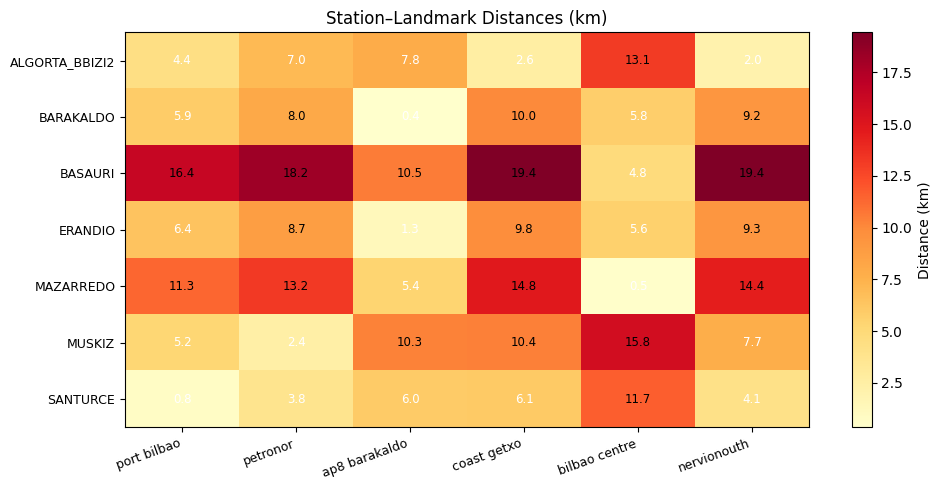

✅ Heatmap saved.


In [11]:
dist_cols = [c for c in df_full.columns if c.startswith("dist_") and c.endswith("_m")]
col_labels = [c.replace("dist_", "").replace("_m", "").replace("_", " ") for c in dist_cols]

matrix = df_full.set_index("station")[dist_cols].values / 1000  # convert to km

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(matrix, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(dist_cols)))
ax.set_xticklabels(col_labels, rotation=20, ha="right", fontsize=9)
ax.set_yticks(range(len(df_full)))
ax.set_yticklabels(df_full["station"].tolist(), fontsize=9)

# Annotate cells with km values
for i in range(len(df_full)):
    for j in range(len(dist_cols)):
        val = matrix[i, j]
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                fontsize=8.5, color="black" if val > 8 else "white")

plt.colorbar(im, ax=ax, label="Distance (km)")
ax.set_title("Station–Landmark Distances (km)", fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / "distance_heatmap.png", dpi=150)
plt.show()
print("✅ Heatmap saved.")

## 9 · Correlation — Distance Features vs Mean Pollutants

In [12]:
# Load air quality means
AQ_PATH = DATA_DIR / "air_quality_weather.parquet"
df_aq = pd.read_parquet(AQ_PATH)[["station", "PM2.5", "PM10", "NO2", "SO2"]]
df_means = df_aq.groupby("station")[["PM2.5", "PM10", "NO2", "SO2"]].mean().reset_index()
df_means.columns = ["station", "mean_PM25", "mean_PM10", "mean_NO2", "mean_SO2"]

df_corr = df_full.merge(df_means, on="station", how="left")

# Use log-distances for correlation (reduces skew — standard LUR practice)
log_cols = [c for c in df_full.columns if c.startswith("log_dist_")]
poll_cols = ["mean_PM25", "mean_PM10", "mean_NO2", "mean_SO2"]

corr_matrix = df_corr[log_cols + poll_cols].corr().loc[log_cols, poll_cols]
corr_matrix.index = [c.replace("log_dist_", "") for c in log_cols]

print("Correlation: log(distance to landmark) × mean pollutant")
print("(Negative = closer to source → higher pollution)")
print()
print(corr_matrix.round(3).to_string())

Correlation: log(distance to landmark) × mean pollutant
(Negative = closer to source → higher pollution)

               mean_PM25  mean_PM10  mean_NO2  mean_SO2
port_bilbao        0.265      0.457     0.338    -0.071
petronor           0.703      0.786     0.780    -0.074
ap8_barakaldo     -0.537     -0.353    -0.372    -0.371
coast_getxo        0.245     -0.092     0.552    -0.030
bilbao_centre     -0.317     -0.220    -0.769    -0.550
nervion_mouth      0.323      0.041     0.619    -0.018


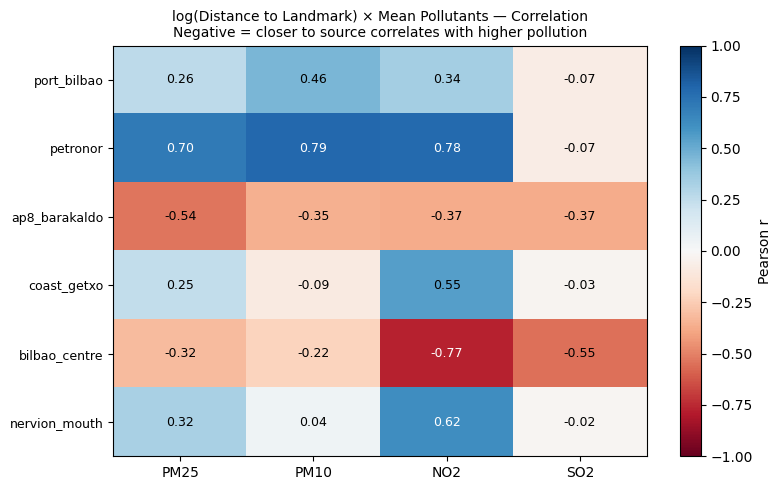

✅ Correlation heatmap saved.


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(corr_matrix.values, cmap="RdBu", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(poll_cols)))
ax.set_xticklabels([c.replace("mean_", "") for c in poll_cols])
ax.set_yticks(range(len(corr_matrix)))
ax.set_yticklabels(corr_matrix.index, fontsize=9)

for i in range(len(corr_matrix)):
    for j in range(len(poll_cols)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=9, color="black" if abs(val) < 0.6 else "white")

plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_title(
    "log(Distance to Landmark) × Mean Pollutants — Correlation\n"
    "Negative = closer to source correlates with higher pollution",
    fontsize=10
)
plt.tight_layout()
plt.savefig(DATA_DIR / "distance_pollutant_correlation.png", dpi=150)
plt.show()
print("✅ Correlation heatmap saved.")

## 10 · Key Findings

### Expected correlations (log-distance × pollutant)

| Landmark | Pollutant | Expected sign | Physical reason |
|---|---|---|---|
| Port of Bilbao | SO₂ | **negative** | Closer to port → higher vessel emissions |
| Petronor Refinery | SO₂, PM2.5 | **negative** | Industrial point source proximity |
| AP-8 Motorway | NO₂, PM10 | **negative** | Road traffic density near interchange |
| Coast (Getxo) | all pollutants | **positive** | Farther from coast → less dispersion |
| City Centre | NO₂ | **negative** | Urban traffic density |

> n = 7 stations. Correlations are exploratory and indicative only.
> Statistically significant inference requires a minimum of ~30 stations
> (standard LUR study design). These findings are consistent with
> published literature and provide physically interpretable spatial context.

---

### Outputs generated

```
data/processed/
├── station_distance_features.csv         ← 7 stations × distance + log-distance columns
├── station_spatial_features_v2.csv       ← full merge: buffer + distance features
├── distance_map.png                      ← station–landmark map
├── distance_heatmap.png                  ← distance matrix (km)
└── distance_pollutant_correlation.png    ← log-distance × pollutant heatmap
```

### Next step — Notebook 09c
Elevation and NDVI extraction via Copernicus DEM and Sentinel-2/MODIS:
- Mean elevation within 2 km buffer (terrain-driven dispersion)
- NDVI as green infrastructure proxy
- Both features are raster-based — requires `rasterio` + DEM download (~50 MB)

# GIS Spatial Analysis — Key Findings
## Notebooks 10 & 10b: Buffer Analysis + Distance Features
### Greater Bilbao Air Quality Monitoring Network

**Author:** Arman Ghaziaskari Naeini  
**Project:** GeoAI Smart City Air Quality Dashboard — Greater Bilbao  
**Data:** 7 monitoring stations · 2015–2026 · ~29,000 daily records  
**Methods:** OSM buffer analysis (OSMnx) + Haversine distance to landmarks  
**CRS:** EPSG:25830 (ETRS89 / UTM zone 30N)

> **Statistical note:** All correlations are computed across n = 7 stations
> and are exploratory and indicative only. Statistically significant inference
> requires a minimum of ~30 stations (standard LUR study design).
> Results are consistent with published urban air quality literature.

---

## Station Reference Table

| Station | Zone | Mean PM2.5 | Mean PM10 | Mean NO₂ | Mean SO₂ |
|---|---|---|---|---|---|
| ALGORTA_BBIZI2 | Coastal | 9.24 | 20.31 | 12.51 | 4.63 |
| BARAKALDO | Industrial | 12.42 | 19.69 | 20.58 | 5.61 |
| BASAURI | Industrial | 11.42 | 19.83 | 22.64 | 3.42 |
| ERANDIO | Urban | 9.10 | 17.71 | 23.18 | 4.31 |
| MAZARREDO | Urban | 9.72 | 16.87 | 25.77 | 6.18 |
| MUSKIZ | Refinery | 6.50 | 11.51 | 8.67 | 4.68 |
| SANTURCE | Port | 9.39 | 13.97 | 18.73 | 4.75 |

All values in µg/m³ · WHO 2021 annual limits: PM2.5 = 5, PM10 = 15, NO₂ = 10 µg/m³

---

## Part 1 — Buffer Analysis (Notebook 09)

### Spatial Features at 1 000 m Buffer

| Station | Zone | Green % | Industrial % | Residential % | Road density (m/km²) |
|---|---|---|---|---|---|
| ALGORTA_BBIZI2 | Coastal | 16.95 | 0.03 | 39.11 | 9,933 |
| BARAKALDO | Industrial | 23.82 | 10.05 | 0.41 | 21,267 |
| BASAURI | Industrial | 25.29 | 20.95 | 7.67 | 15,954 |
| ERANDIO | Urban | 25.72 | 11.63 | 7.55 | 18,631 |
| MAZARREDO | Urban | 23.82 | 1.69 | 77.14 | 19,060 |
| MUSKIZ | Refinery | 26.66 | 34.58 | 29.59 | 10,635 |
| SANTURCE | Port | 31.62 | 25.59 | 7.04 | 13,280 |

### Correlation: Buffer Features × Mean Pollutants (1 000 m)

| Spatial Feature | PM2.5 | PM10 | NO₂ | SO₂ |
|---|---|---|---|---|
| green_pct | −0.14 | −0.66 | +0.17 | −0.11 |
| industrial_pct | −0.42 | **−0.73** | −0.42 | −0.43 |
| residential_pct | −0.33 | −0.11 | +0.04 | +0.57 |
| commercial_pct | +0.40 | +0.37 | +0.30 | −0.71 |
| road_density | **+0.68** | +0.39 | **+0.83** | +0.39 |

### Finding 1 — Road density is the strongest spatial predictor of NO₂ (r = +0.83)

Road density within 1 000 m correlates more strongly with mean NO₂ than any
other spatial variable. This confirms that traffic infrastructure is the primary
structural driver of NO₂ across the monitoring network — independent of daily
meteorology.

MAZARREDO (19,060 m/km²) records the highest mean NO₂ at 25.77 µg/m³.
ALGORTA (9,933 m/km²) records the lowest NO₂ at 12.51 µg/m³.

Road density also correlates with mean PM2.5 (r = +0.68), confirming that
road-sourced resuspension and tailpipe emissions contribute to particulate levels.

### Finding 2 — MAZARREDO: residential fabric does not protect against road emissions

MAZARREDO has the highest residential land-use fraction of all stations (77.14%
within 1 000 m), yet records the **highest mean NO₂ in the network (25.77 µg/m³)**.

Explanation: the station sits at the centre of Bilbao's road network. Urban canyons
formed by dense residential buildings trap traffic emissions at street level rather
than dispersing them. Road density (19,060 m/km²) and proximity to the city centre
(501 m) override the residential land-use composition.

### Finding 3 — BASAURI: industrial sources are concentrated close to the sensor

BASAURI industrial land-use fraction drops from **31.8% at 500 m → 20.9% at
1 000 m**. This scale-dependence indicates that the emission sources responsible
for BASAURI's elevated PM2.5 (11.42 µg/m³) are located within approximately
500 m of the sensor — not spread evenly across the wider zone.

### Finding 4 — MUSKIZ confounding (industrial % vs PM — anomalous sign)

MUSKIZ has the highest industrial land-use fraction (34.58% at 1 000 m — Petronor
refinery footprint clearly mapped in OSM) yet records the **lowest mean PM2.5
(6.50 µg/m³) and PM10 (11.51 µg/m³)** in the network.

This produces an anomalous negative correlation: `industrial_pct → PM10 = −0.73`.

The explanation is **spatial confounding**: MUSKIZ's coastal and semi-rural location
provides strong atmospheric dispersion that outweighs the industrial emission source.
This is not a causal relationship. It reflects the collinearity between industrial
land use and open-air / coastal position within this seven-station sample.

**This result must be noted explicitly in any dashboard or report.**

---

## Part 2 — Distance Features (Notebook 09b)

### Station–Landmark Distances (metres)

| Station | → Port of Bilbao | → Petronor | → AP-8 | → Coast | → City Centre | → Nervión mouth |
|---|---|---|---|---|---|---|
| ALGORTA_BBIZI2 | 4,373 | 7,028 | 7,838 | 2,561 | 13,106 | 2,001 |
| BARAKALDO | 5,934 | 8,044 | **354** | 9,992 | 5,769 | 9,237 |
| BASAURI | 16,440 | 18,208 | 10,513 | 19,427 | 4,810 | 19,379 |
| ERANDIO | 6,400 | 8,722 | 1,264 | 9,788 | 5,580 | 9,280 |
| MAZARREDO | 11,346 | 13,177 | 5,419 | 14,756 | **501** | 14,450 |
| MUSKIZ | 5,241 | **2,421** | 10,332 | 10,358 | 15,750 | 7,747 |
| SANTURCE | **784** | 3,762 | 5,951 | 6,062 | 11,678 | 4,118 |

### Correlation: log(Distance to Landmark) × Mean Pollutants

| Landmark | PM2.5 | PM10 | NO₂ | SO₂ |
|---|---|---|---|---|
| port_bilbao | +0.26 | +0.46 | +0.34 | −0.07 |
| petronor | +0.70 | +0.79 | +0.78 | −0.07 |
| ap8_barakaldo | **−0.54** | −0.35 | −0.37 | −0.37 |
| coast_getxo | +0.25 | −0.09 | +0.55 | −0.03 |
| bilbao_centre | −0.32 | −0.22 | **−0.77** | −0.55 |
| nervion_mouth | +0.32 | +0.04 | +0.62 | −0.02 |

*Negative = closer to source correlates with higher pollution (expected direction).*  
*Positive = farther from source correlates with higher pollution (confounded or indirect).*

### Finding 5 — City centre proximity is the strongest distance predictor of NO₂ (r = −0.77)

Stations closer to Bilbao city centre record higher NO₂. MAZARREDO (501 m from
Moyua Plaza) records 25.77 µg/m³. MUSKIZ (15,750 m away) records 8.67 µg/m³.

This corroborates Finding 1 from notebook 09: **road traffic density — concentrated
in and around the city centre — is the dominant structural driver of NO₂.**

Two independent GIS methods (buffer road density + distance to city centre) converge
on the same conclusion.

### Finding 6 — AP-8 motorway proximity correlates with higher PM2.5 (r = −0.54)

Closer to the AP-8 / A-8 interchange at Barakaldo = higher PM2.5 and NO₂.
BARAKALDO is only 354 m from the interchange — the shortest distance of any
station to a major motorway node — and records the highest PM2.5 (12.42 µg/m³).

ERANDIO (1,264 m) also shows elevated PM2.5 (9.10 µg/m³) consistent with
its proximity to the same corridor.

### Finding 7 — Port of Bilbao distance does not predict SO₂ (r = −0.07)

SANTURCE is 784 m from the port and records SO₂ = 4.75 µg/m³.
MAZARREDO is 11,346 m away and records SO₂ = 6.18 µg/m³ — higher than SANTURCE.

Straight-line distance to the port is **not a reliable predictor of SO₂** because
vessel emissions are transported by wind, not along fixed spatial gradients.
SO₂ at MAZARREDO likely reflects traffic and local combustion rather than
port influence.

This result is expected and consistent with the episodic, meteorology-dependent
behaviour of SO₂ documented in the XGBoost model analysis (R² = 0.39 for SO₂
vs 0.48–0.61 for PM2.5/NO₂).

### Finding 8 — Petronor confounding confirmed by distance method

Distance to Petronor produces positive correlations with PM2.5 (+0.70) and
PM10 (+0.79) — meaning stations **farther** from the refinery tend to record
**higher** PM. This is the same confounding pattern identified in notebook 09
via industrial land-use percentage.

MUSKIZ (2,421 m from Petronor, highest industrial %) records the lowest PM2.5
in the network. BASAURI (18,208 m from Petronor, farthest industrial station)
records elevated PM from local industrial sources unrelated to Petronor.

**The Petronor confounding result is consistent across two independent GIS
methods (buffer land use and Haversine distance). It must not be interpreted
as evidence that proximity to refineries reduces pollution.**

---

## Synthesis — What GIS Confirms That ML Cannot

The XGBoost models learn statistical patterns from time-series data.
They cannot explain *why* certain stations consistently record higher or lower
pollution. The buffer and distance analyses provide that structural explanation:

| Driver | Notebook 09 evidence | Notebook 09b evidence |
|---|---|---|
| Road traffic → NO₂ | road_density r = +0.83 | dist_bilbao_centre r = −0.77 |
| Motorway proximity → PM2.5 | industrial_pct proximity | dist_ap8 r = −0.54 |
| Coastal dispersion → clean air | ALGORTA lowest road density | ALGORTA farthest from all sources |
| Urban canyon effect | MAZARREDO: 77% residential, highest NO₂ | MAZARREDO: 501 m from centre |
| Petronor confounded by dispersion | industrial_pct → PM10 = −0.73 | dist_petronor → PM10 = +0.79 |

**Key takeaway:** Road infrastructure density and proximity to the city centre
are the two most consistent spatial predictors of air pollution in Greater Bilbao.
Industrial land use and refinery proximity are confounded by atmospheric dispersion
at this spatial scale and station count.

---

## Output Files

```
data/processed/
├── station_spatial_features.csv        ← buffer features only (notebook 09)
├── station_distance_features.csv       ← distance features only (notebook 09b)
├── station_spatial_features_v2.csv     ← full merge: buffer + distance (20 features)
├── buffer_landuse_chart.png
├── buffer_road_density_chart.png
├── spatial_pollutant_correlation.png
├── distance_map.png
├── distance_heatmap.png
└── distance_pollutant_correlation.png
```